# 🏙️ PropertyIQ: A 20-Minute Data Visualization Sprint
### Unit 1 — Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) (Kaggle)

---

## 📖 The Scenario

You have just joined **PropertyIQ**, a Melbourne-based real-estate analytics startup, as a **junior data analyst**.

Tomorrow morning, your **Head of Sales** is meeting a client — a property investment fund — and needs a short briefing built from the `melb_data.csv` housing snapshot. She has given you **20 minutes** to turn the raw data into something she can actually present.

She says:

> *"I don't want a data dump. I want to walk in, show three good visuals, and leave the client with one clear takeaway. Make sure the charts are the right *type*, saved in the right *format*, and that the design doesn't get in the way of the message."*

This activity walks you through exactly the workflow described in the lecture: **understand the context → choose the right chart → choose the right file format → separate content from design → tell the story.**




## Part 0 — Setup (1 min)

1. Download **`melb_data.csv`** from the [Kaggle dataset page](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot).
2. Place it in the **same folder** as this notebook.
3. Run the cell below.

*(If the file isn't found, the cell will auto-generate a small synthetic stand-in with the same columns, so you can still complete the activity — just swap in the real CSV later.)*


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

DATA_PATH = "melb_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("melb_data.csv not found — generating a small synthetic stand-in so you can still run the activity.")
    n = 600
    regions = ["Northern Metropolitan", "Western Metropolitan", "Southern Metropolitan",
               "Eastern Metropolitan", "South-Eastern Metropolitan"]
    types = ["h", "u", "t"]  # house, unit, townhouse
    df = pd.DataFrame({
        "Suburb": np.random.choice(["Richmond", "Brunswick", "Carlton", "Footscray",
                                     "St Kilda", "Fitzroy", "Camberwell"], n),
        "Rooms": np.random.randint(1, 6, n),
        "Type": np.random.choice(types, n, p=[0.6, 0.3, 0.1]),
        "Price": np.random.lognormal(mean=13.5, sigma=0.4, size=n).round(-3),
        "Distance": np.round(np.random.exponential(8, n), 1),
        "Landsize": np.random.exponential(400, n).round(0),
        "BuildingArea": np.random.normal(150, 50, n).clip(30, 500).round(0),
        "YearBuilt": np.random.randint(1900, 2018, n),
        "Regionname": np.random.choice(regions, n),
        "Bathroom": np.random.randint(1, 4, n),
        "Car": np.random.randint(0, 4, n),
    })

df.head()


Loaded real dataset: 13580 rows, 20 columns


,Date,Suburb,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Price
0,23/09/2017,Aberfeldie,5,h,S,Rendina,7.5,3040,5,4,4.0,730,373.0,2014.0,NaN,-37.75950,144.89427,Western Metropolitan,1543,1830000
1,23/09/2017,Airport West,3,h,S,Brad,10.4,3042,3,1,2.0,551,96.0,1950.0,NaN,-37.72739,144.88235,Western Metropolitan,3464,850000
2,23/09/2017,Airport West,3,h,S,Harcourts,10.4,3042,3,2,2.0,593,NaN,NaN,NaN,-37.72057,144.87558,Western Metropolitan,3464,860000
3,23/09/2017,Albanvale,3,h,S,Bells,14.0,3021,3,1,2.0,619,NaN,NaN,NaN,-37.74521,144.76863,Western Metropolitan,1899,565000
4,23/09/2017,Albert Park,3,h,VB,Cayzer,3.0,3206,3,2,NaN,137,125.0,1890.0,NaN,-37.84388,144.95303,Southern Metropolitan,3280,2100000


## Part 1 — Understand the Context (3 min)

> *"Good data visualization begins with understanding the problem, not by choosing a chart."*

Recall the lecture's distinction:

| Exploratory Analysis | Explanatory Analysis |
|---|---|
| Explores data to discover patterns | Communicates a clear insight |
| Multiple hypotheses tested | One key message emphasized |
| Used by the analyst | Designed for the audience |

**Run the cell below** to get a quick feel for the data (this is *exploratory* — you're doing it for yourself, not the client).


In [ ]:
df.info()
df.describe(include="all").T.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           13580 non-null  object 
 1   Suburb         13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Method         13580 non-null  object 
 5   SellerG        13580 non-null  object 
 6   Distance       13580 non-null  float64
 7   Postcode       13580 non-null  int64  
 8   Bedroom2       13580 non-null  int64  
 9   Bathroom       13580 non-null  int64  
 10  Car            13518 non-null  float64
 11  Landsize       13580 non-null  int64  
 12  BuildingArea   7130 non-null   float64
 13  YearBuilt      8205 non-null   float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  object 
 18  Proper

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,13580,58,27/05/2017,473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Suburb,13580,314,Reservoir,359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rooms,13580.0,NaN,NaN,NaN,2.937997,0.955748,1.0,2.0,3.0,3.0,10.0
Type,13580,3,h,9449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method,13580,5,S,9022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SellerG,13580,268,Nelson,1565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance,13580.0,NaN,NaN,NaN,10.137776,5.868725,0.0,6.1,9.2,13.0,48.1
Postcode,13580.0,NaN,NaN,NaN,3105.301915,90.676964,3000.0,3044.0,3084.0,3148.0,3977.0
Bedroom2,13580.0,NaN,NaN,NaN,2.914728,0.965921,0.0,2.0,3.0,3.0,20.0
Bathroom,13580.0,NaN,NaN,NaN,1.534242,0.691712,0.0,1.0,1.0,2.0,8.0


### ✍️ Your turn (fill in the markdown cell below)

Answer in 1–2 sentences each:

1. **Who** is the audience for the visuals you're about to build (recall the scenario)?
2. Is the work you just did (`df.info()`, `df.describe()`) *exploratory* or *explanatory*? Why?
3. What is **one** question that the investment fund client would actually care about?


**Your answers:**

1. Audience:
The audience is the property investment fund client, represented by the Head of Sales, who wants to understand the Melbourne housing market and make investment decisions.

2. Exploratory or explanatory, and why:
This work is exploratory because df.info() and df.describe() are used to understand the dataset, its structure, columns, and basic statistics before creating visuals or communicating findings.

3. A question the client cares about:
Which regions have the highest average property prices, and where might the best investment opportunities be?


## Part 2 — Choosing the Right Chart (7 min)

Recall the recommendation table from the lecture:

| Purpose | Recommended Chart |
|---|---|
| Compare categories | Bar Chart |
| Show trends | Line Chart |
| Show relationships | Scatter Plot |
| Show distributions | Histogram / Box Plot |
| Show proportions | Stacked Bar (limited categories) |

Your Head of Sales wants **three** visuals for the briefing. For each question below:
1. Write down which chart type is appropriate (and *why*, referencing the table).
2. Fill in the `# TODO` in the code to build it.

Avoid choosing a chart just because it "looks nice" — first identify what question it needs to answer.


### 2.1 — "How do average prices differ across regions?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**
A bar chart is appropriate because we are comparing a numerical value (average price) across different categories (regions). The lecture recommends bar charts for comparing categories.


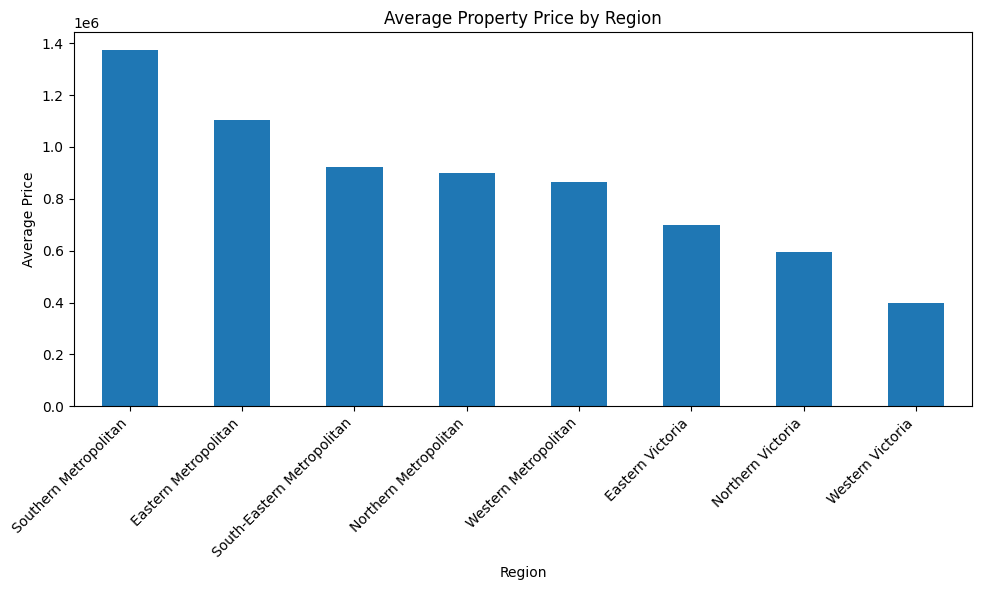

In [ ]:
# Calculate average price by region
avg_price_region = df.groupby("Regionname")["Price"].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
avg_price_region.plot(kind="bar")

plt.title("Average Property Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 2.2 — "Is there a relationship between land size and price?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**
A scatter plot is appropriate because we are examining the relationship between two numerical variables — Landsize and Price. The lecture recommends scatter plots for showing relationships between variables.


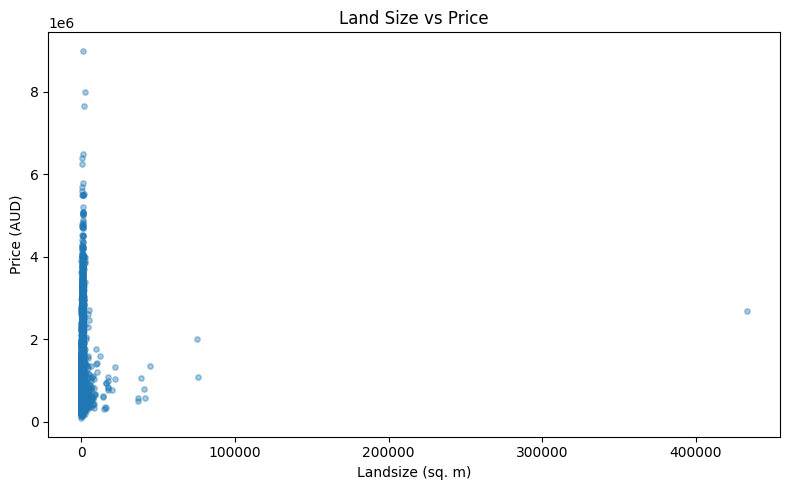

In [ ]:
# Build a chart that shows the relationship between Landsize and Price

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["Landsize"], df["Price"], alpha=0.4, s=15)

ax.set_xlabel("Landsize (sq. m)")
ax.set_ylabel("Price (AUD)")
ax.set_title("Land Size vs Price")
plt.tight_layout()
plt.show()

### 2.3 — "What does the overall spread of prices in the market look like?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**
A histogram is appropriate because we want to see the distribution/spread of property prices across the market. The lecture recommends histograms (or box plots) for showing distributions, helping us see where most prices are concentrated and whether there are unusually high or low prices.


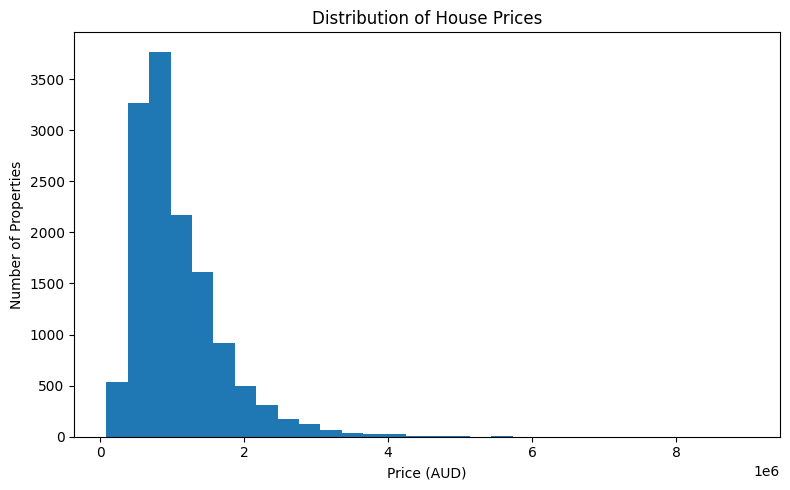

In [ ]:
# Build a chart that shows the distribution of Price

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df["Price"].dropna(), bins=30)

ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Number of Properties")
ax.set_title("Distribution of House Prices")
plt.tight_layout()
plt.show()

## Part 3 — Image Formats & Compression (4 min)

Recall:
- **Bitmap** (PNG, JPEG) = pixels, fixed resolution. **Vector** (SVG, PDF) = shapes, resolution-independent.
- **Lossless** (PNG, TIFF) = no data removed. **Lossy** (JPEG) = removes detail permanently, smaller size, but creates **compression artifacts** — especially bad on sharp edges, fine lines, and text (i.e. **charts**).

Let's prove it. Save your region bar chart from Part 2.1 as **both** PNG and JPEG, and compare.


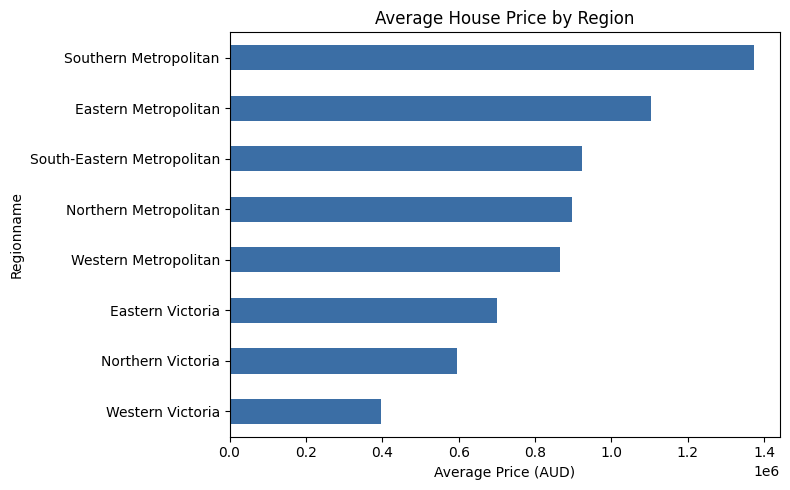

PNG size: 56.2 KB
JPEG size: 67.3 KB


In [ ]:
region_avg = df.groupby("Regionname")["Price"].mean().sort_values(ascending=True)
import os

fig, ax = plt.subplots(figsize=(8, 5))

region_avg.plot(kind="barh", ax=ax, color="#3b6ea5")

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")

plt.tight_layout()

# Save the SAME chart in two formats
fig.savefig("region_chart.png", dpi=150)
fig.savefig("region_chart.jpg", dpi=150)

plt.show()

# Compare file sizes
png_size = os.path.getsize("region_chart.png")
jpg_size = os.path.getsize("region_chart.jpg")

print(f"PNG size: {png_size/1024:.1f} KB")
print(f"JPEG size: {jpg_size/1024:.1f} KB")

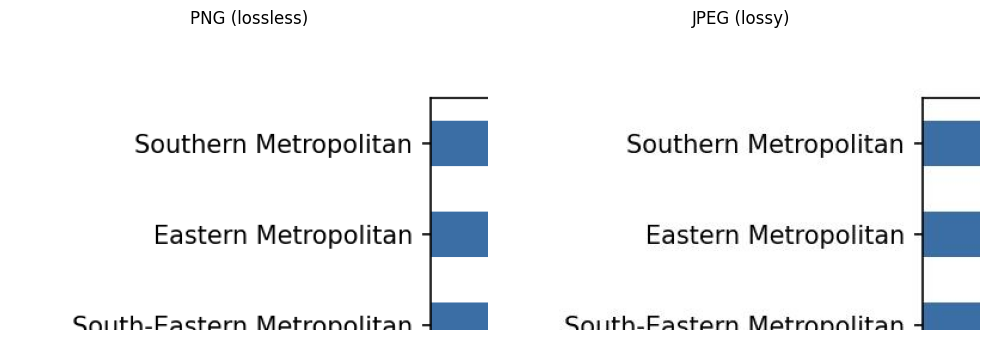

In [ ]:
# Zoom into a saved image to inspect for compression artifacts around the text/edges
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, fname, label in zip(axes, ["region_chart.png", "region_chart.jpg"], ["PNG (lossless)", "JPEG (lossy)"]):
    img = Image.open(fname)
    w, h = img.size
    crop = img.crop((0, 0, w // 3, h // 3))  # zoom into top-left corner (title/text area)
    ax.imshow(crop)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()


### ✍️ Your turn

1. Which file was larger — PNG or JPEG? Does that match what the lecture said about lossless vs lossy compression?
2. Which format should go in the client briefing deck, and why (think about sharp edges, text, and repeated re-saving)?

**Your answers:**

1. 1. **Which file was larger — PNG or JPEG? Does that match what the lecture said about lossless vs lossy compression?**
   PNG was larger than JPEG. Yes, this matches the lecture because PNG uses lossless compression, while JPEG uses lossy compression and usually produces a smaller file.

2. **Which format should go in the client briefing deck, and why?**
   PNG should be used for the client briefing deck because it preserves sharp edges, text, and fine details better. JPEG is lossy, so repeated re-saving can reduce image quality and introduce compression artifacts.


## Part 4 — Separating Content from Design (3 min)

> *"Changing a theme should not change the data."*

**Content** = data, variables, axes, plot type. **Design** = colors, fonts, gridlines, theme, labels.

Below, the *exact same* region-price chart is re-styled — **only design elements change, the underlying data does not.**


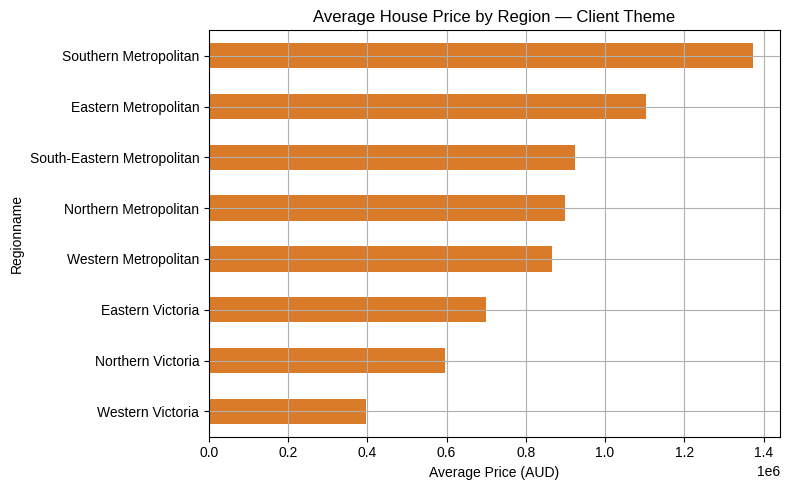

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "ggplot")

# SAME region_avg data — only styling changes
region_avg.plot(kind="barh", ax=ax, color="#d97b29")

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region — Client Theme")
plt.tight_layout()
plt.show()

plt.style.use("default")  # reset

### ✍️ Your turn

Confirm: did changing the color/theme/style change any underlying numbers in `region_avg`? *(It shouldn't have.)* Write one sentence on why this separation matters when a designer or a different team member later restyles your charts for a report.

**Your answer:**
No, changing the color/theme/style did not change any underlying numbers in region_avg; keeping data separate from design matters because different team members can restyle the chart without changing or accidentally altering the actual analysis.

## Part 5 — The Big Idea (2 min, wrap-up)

Recall the lecture's **3-Minute Story** and **Big Idea** techniques:

> *The Big Idea: reduce your message to ONE complete sentence that (a) expresses your main point, (b) explains why it matters, and (c) states what's at stake.*

### ✍️ Final task

Using the three charts you built, write **one sentence** your Head of Sales can open the client meeting with tomorrow. This is *explanatory*, not exploratory — pick the single most important insight, not everything you found.

**Your Big Idea:**

> Property prices vary substantially across Melbourne regions and generally rise with land size, highlighting clear differences in investment value and making location and property size important factors for the fund’s investment decisions.

---

### ✅ Quick self-check
1. Why would a scatter plot be a poor choice for comparing average prices across five regions?
A scatter plot is meant to show the relationship between two numerical variables, whereas regions are categories, so a bar chart is better for comparing their average prices.
2. Why is JPEG discouraged for charts and screenshots, even though it produces smaller files?
JPEG uses lossy compression, which can create artifacts and reduce the sharpness of text, edges, and fine lines in charts and screenshots.
3. Name one thing that counts as "design" (not "content") in a chart.
The color of the bars is an example of design. 🎨
